# Urban Sound Classification Using SpeechBrain

This notebook demonstrates urban sound classification using the pre-trained SpeechBrain model instead of training a custom DNN. We'll use the UrbanSound8K dataset for evaluation and comparison.

## Importing Required Libraries

In [9]:
# Core libraries
import pandas as pd
import numpy as np
import os
import librosa
import librosa.display
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

# SpeechBrain for audio classification
import torch
import torchaudio
from speechbrain.inference import EncoderClassifier

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pickle

plt.style.use('seaborn-v0_8')

## Dataset Setup and Configuration

In [2]:
# Dataset paths
data_path = 'D:/Projects/UrbanNoiseClassifier/project/audio-classifier/data/raw/UrbanSound8K/UrbanSound8K/'
csv_path = os.path.join(data_path, 'metadata/UrbanSound8K.csv')
audio_path = os.path.join(data_path, 'audio/')

# Class names for UrbanSound8K
class_names = ["air_conditioner", "car_horn", "children_playing", "dog_bark", 
               "drilling", "engine_idling", "gun_shot", "jackhammer", 
               "siren", "street_music"]

# Load the dataset metadata
data = pd.read_csv(csv_path)
print(f"Dataset loaded: {len(data)} samples")
data.head()

Dataset loaded: 8732 samples


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


# Exploratory Data Analysis

Let's explore the dataset structure and distribution of classes.

In [3]:
# Basic dataset information
print("Dataset Information:")
print(f"Shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nMissing values: {data.isnull().sum().sum()}")
print(f"\nUnique classes: {data['class'].nunique()}")
print(f"Classes: {sorted(data['class'].unique())}")

Dataset Information:
Shape: (8732, 8)

Columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']

Missing values: 0

Unique classes: 10
Classes: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


## Class Distribution Analysis

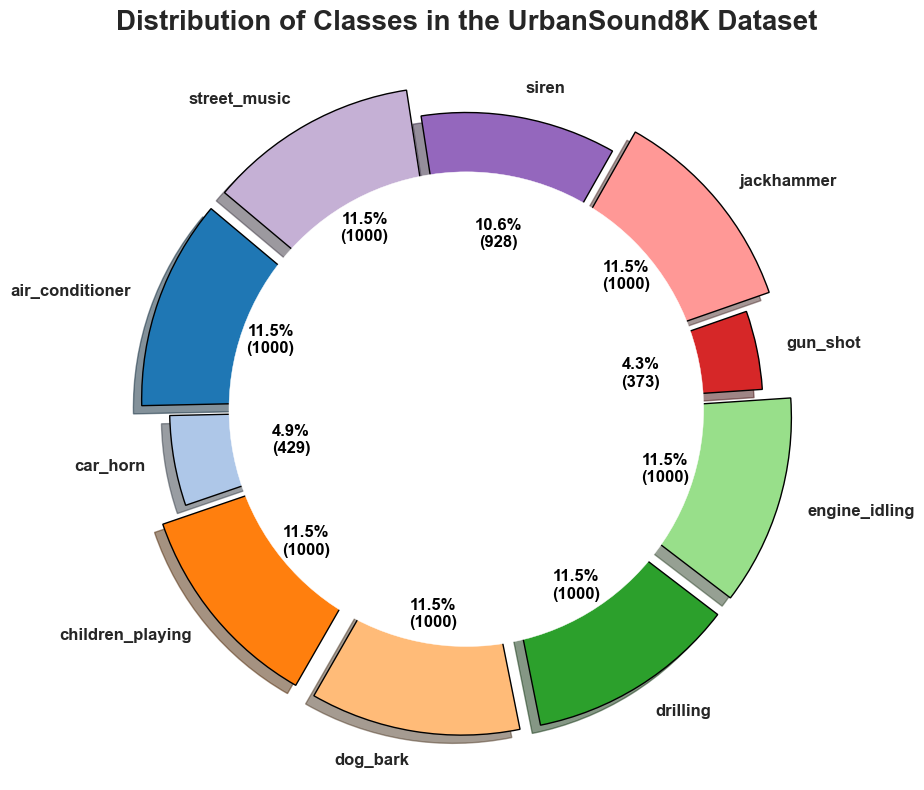


Class distribution:
air_conditioner: 1000 samples (11.5%)
car_horn: 429 samples (4.9%)
children_playing: 1000 samples (11.5%)
dog_bark: 1000 samples (11.5%)
drilling: 1000 samples (11.5%)
engine_idling: 1000 samples (11.5%)
gun_shot: 374 samples (4.3%)
jackhammer: 1000 samples (11.5%)
siren: 929 samples (10.6%)
street_music: 1000 samples (11.5%)


In [4]:
# Class distribution visualization
class_distribution = data['class'].value_counts().sort_index()

def func(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

explode = [0.1 if i == class_distribution.max() else 0 for i in class_distribution]
colors = plt.cm.tab20.colors  

wedges, texts, autotexts = plt.pie(
    class_distribution, 
    labels=class_distribution.index, 
    autopct=lambda pct: func(pct, class_distribution),
    startangle=140, 
    colors=colors, 
    explode=explode, 
    shadow=True, 
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)

plt.setp(autotexts, size=12, weight='bold', color='black')
plt.setp(texts, size=12, weight='bold')
plt.title('Distribution of Classes in the UrbanSound8K Dataset', fontsize=20, weight='bold')

centre_circle = plt.Circle((0, 0), 0.80, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()

print("\nClass distribution:")
for class_name, count in class_distribution.items():
    print(f"{class_name}: {count} samples ({count/len(data)*100:.1f}%)")

## Audio Sample Visualization

Class: jackhammer
File: 177537-7-0-3.wav
Duration: 4.00 seconds
Sample Rate: 22050 Hz


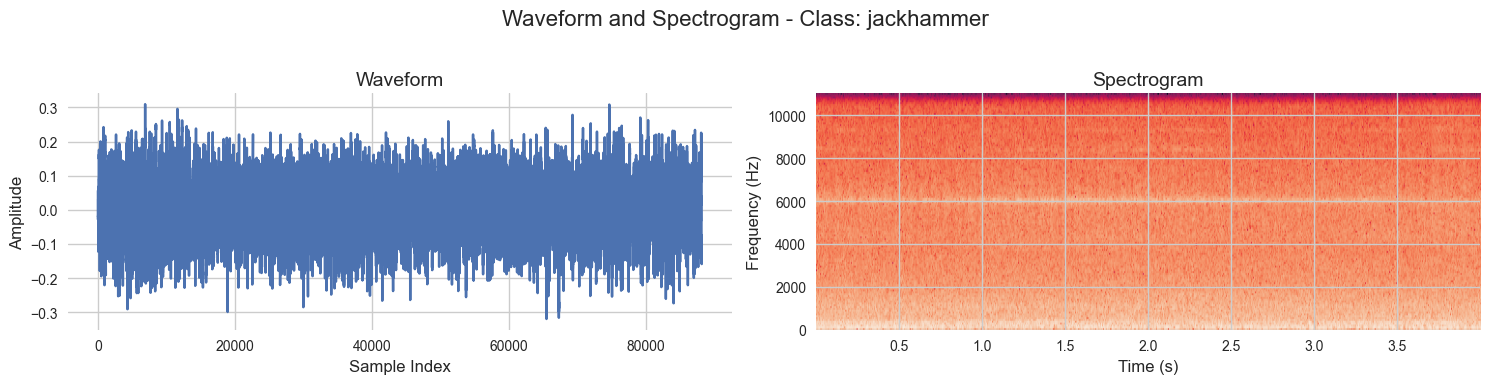

In [5]:
# Display a random audio sample with waveform and spectrogram
row = data.sample(1).iloc[0]

# Construct file path
audioFile = os.path.join(audio_path, 'fold' + str(row['fold']), row['slice_file_name'])

# Load audio file
waveform, sampleRate = librosa.load(audioFile)

# Display audio
print(f"Class: {row['class']}")
print(f"File: {row['slice_file_name']}")
print(f"Duration: {len(waveform)/sampleRate:.2f} seconds")
print(f"Sample Rate: {sampleRate} Hz")
ipd.display(ipd.Audio(waveform, rate=sampleRate))

# Plot configuration
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle(f'Waveform and Spectrogram - Class: {row["class"]}', fontsize=16)

# Display waveform
axs[0].plot(waveform)
axs[0].set_title('Waveform', fontsize=14)
axs[0].set_xlabel('Sample Index', fontsize=12)
axs[0].set_ylabel('Amplitude', fontsize=12)

# Display spectrogram
axs[1].specgram(waveform, Fs=sampleRate)
axs[1].set_title('Spectrogram', fontsize=14)
axs[1].set_xlabel('Time (s)', fontsize=12)
axs[1].set_ylabel('Frequency (Hz)', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Mel Spectrogram Visualization

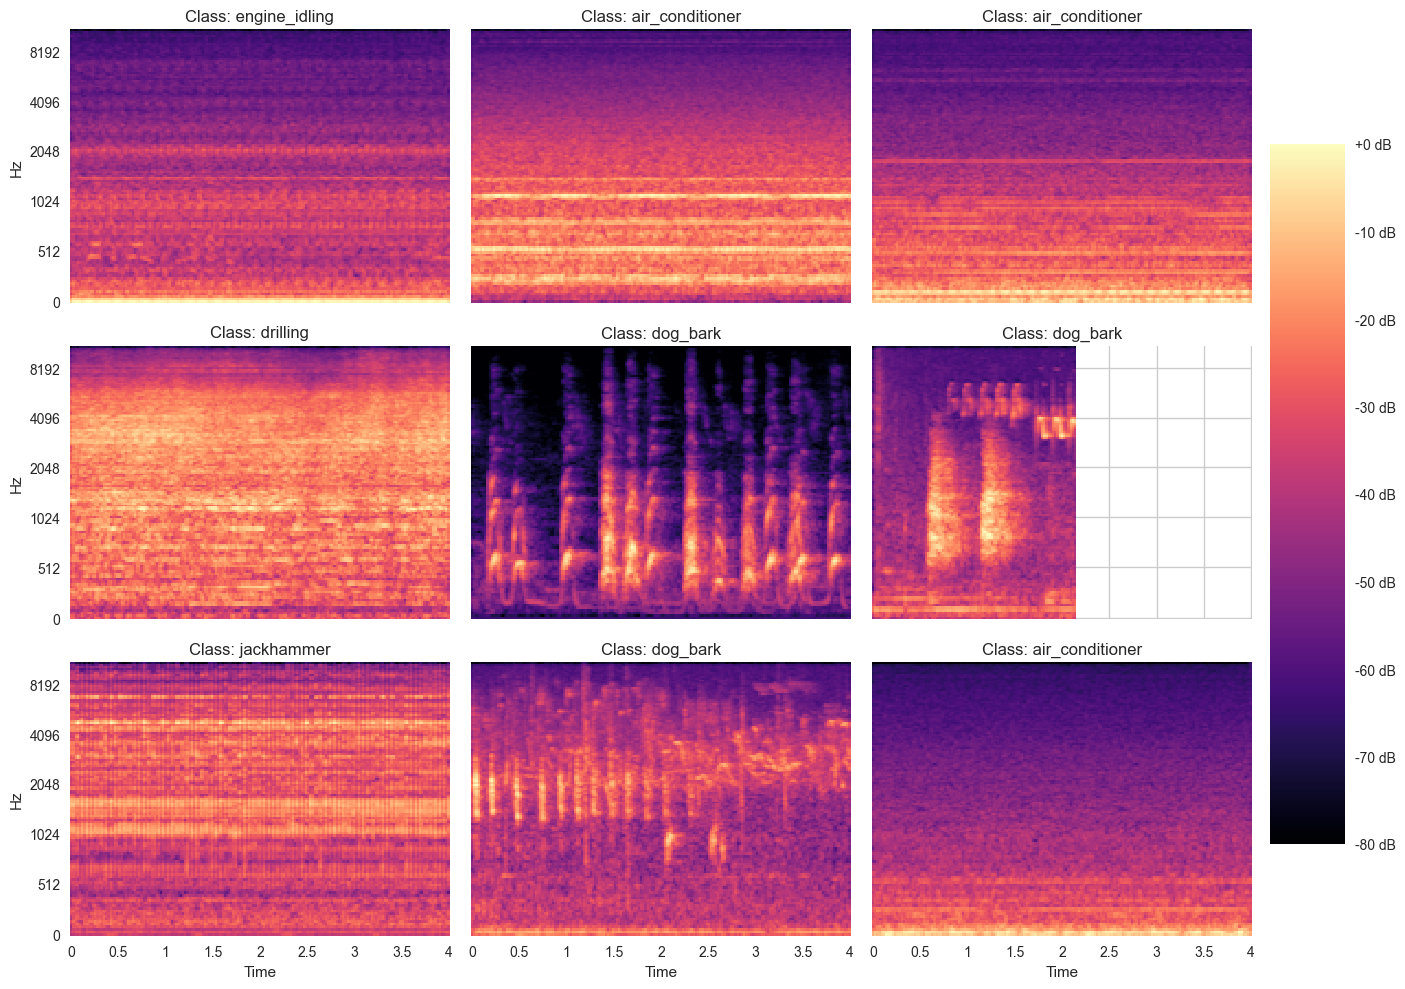

In [6]:
# Display mel spectrograms for sample files from each class
sample_files = data.sample(9)   # Randomly select 9 files for display

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex='col', sharey='row')
for i, (idx, row) in enumerate(sample_files.iterrows()):
    file_path = os.path.join(audio_path, 'fold'+str(row['fold']), row['slice_file_name'])
    y, sr = librosa.load(file_path)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    ax = axes[i // 3, i % 3]
    img = librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title('Class: ' + str(row['class']))
    ax.label_outer()

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(img, cax=cbar_ax, format='%+2.0f dB')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# SpeechBrain Model Setup

Now let's load the pre-trained SpeechBrain model for urban sound classification.

In [7]:
# Load the pre-trained SpeechBrain model
print("Loading SpeechBrain UrbanSound8K classifier...")
classifier = EncoderClassifier.from_hparams(
    source="speechbrain/urbansound8k_ecapa", 
    savedir="pretrained_models/urbansound8k_ecapa"
)
print("Model loaded successfully!")

Loading SpeechBrain UrbanSound8K classifier...
Model loaded successfully!
Model loaded successfully!


## Test Single Audio File

In [11]:
# Test the model with a single file
test_row = data.sample(1).iloc[0]
test_file = os.path.join(audio_path, 'fold' + str(test_row['fold']), test_row['slice_file_name'])

print(f"Testing file: {test_row['slice_file_name']}")
print(f"True class: {test_row['class']}")

# Classify the audio file
out_prob, score, index, predicted_class = classifier.classify_file(test_file)
confidence = torch.max(out_prob).item() * 100

# Extract the class name from list if it's returned as a list
if isinstance(predicted_class, list):
    predicted_class = predicted_class[0]

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print(f"Prediction correct: {predicted_class == test_row['class']}")

# Display the audio
waveform, sr = librosa.load(test_file)
ipd.display(ipd.Audio(waveform, rate=sr))

Testing file: 94632-5-0-14.wav
True class: engine_idling
Predicted class: engine_idling
Confidence: 89.33%
Prediction correct: True


# Comprehensive Evaluation

Let's evaluate the SpeechBrain model on the entire UrbanSound8K dataset using the 10-fold cross-validation structure.

In [14]:
def evaluate_speechbrain_model(data, audio_path, classifier, fold=None):
    """
    Evaluate the SpeechBrain model on a subset of data (fold or entire dataset)
    """
    if fold is not None:
        eval_data = data[data['fold'] == fold]
        print(f"Evaluating on fold {fold} ({len(eval_data)} samples)...")
    else:
        eval_data = data
        print(f"Evaluating on entire dataset ({len(eval_data)} samples)...")
    
    true_labels = []
    predicted_labels = []
    confidences = []
    failed_files = []
    
    for idx, row in tqdm(eval_data.iterrows(), total=len(eval_data), desc="Classifying"):
        audio_file = os.path.join(audio_path, 'fold' + str(row['fold']), row['slice_file_name'])
        
        try:
            # Classify the audio file
            out_prob, score, index, predicted_class = classifier.classify_file(audio_file)
            confidence = torch.max(out_prob).item()
            
            # Extract the class name from list if it's returned as a list
            if isinstance(predicted_class, list):
                predicted_class = predicted_class[0]
            
            true_labels.append(row['class'])
            predicted_labels.append(predicted_class)
            confidences.append(confidence)
            
        except Exception as e:
            failed_files.append((row['slice_file_name'], str(e)))
            continue
    
    if failed_files:
        print(f"Failed to process {len(failed_files)} files")
    
    return true_labels, predicted_labels, confidences, failed_files

## 10-Fold Cross-Validation Evaluation

In [15]:
# Evaluate on each fold (simulating cross-validation)
fold_results = {}
all_true_labels = []
all_predicted_labels = []
all_confidences = []

for fold in range(1, 11):
    print(f"\n{'='*50}")
    print(f"Evaluating Fold {fold}")
    print(f"{'='*50}")
    
    true_labels, predicted_labels, confidences, failed_files = evaluate_speechbrain_model(
        data, audio_path, classifier, fold=fold
    )
    
    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(true_labels, predicted_labels)
    fold_results[fold] = {
        'accuracy': fold_accuracy,
        'samples': len(true_labels),
        'failed': len(failed_files),
        'mean_confidence': np.mean(confidences)
    }
    
    print(f"Fold {fold} Results:")
    print(f"  Accuracy: {fold_accuracy:.4f} ({fold_accuracy*100:.2f}%)")
    print(f"  Samples processed: {len(true_labels)}")
    print(f"  Failed samples: {len(failed_files)}")
    print(f"  Mean confidence: {np.mean(confidences):.4f}")
    
    # Accumulate all results
    all_true_labels.extend(true_labels)
    all_predicted_labels.extend(predicted_labels)
    all_confidences.extend(confidences)


Evaluating Fold 1
Evaluating on fold 1 (873 samples)...


Classifying: 100%|██████████| 873/873 [00:21<00:00, 40.46it/s]


Fold 1 Results:
  Accuracy: 0.9737 (97.37%)
  Samples processed: 873
  Failed samples: 0
  Mean confidence: 0.7418

Evaluating Fold 2
Evaluating on fold 2 (888 samples)...


Classifying: 100%|██████████| 888/888 [00:20<00:00, 43.03it/s]


Fold 2 Results:
  Accuracy: 0.9764 (97.64%)
  Samples processed: 888
  Failed samples: 0
  Mean confidence: 0.7429

Evaluating Fold 3
Evaluating on fold 3 (925 samples)...


...

Fold 8 Results:
  Accuracy: 0.9677 (96.77%)
  Samples processed: 806
  Failed samples: 0
  Mean confidence: 0.7486

Evaluating Fold 9
Evaluating on fold 9 (816 samples)...


Classifying: 100%|██████████| 816/816 [00:18<00:00, 44.50it/s]


Fold 9 Results:
  Accuracy: 0.7598 (75.98%)
  Samples processed: 816
  Failed samples: 0
  Mean confidence: 0.6295

Evaluating Fold 10
Evaluating on fold 10 (837 samples)...


Classifying: 100%|██████████| 837/837 [00:18<00:00, 45.30it/s]

Fold 10 Results:
  Accuracy: 0.7300 (73.00%)
  Samples processed: 837
  Failed samples: 0
  Mean confidence: 0.6319


## Overall Results Summary

In [16]:
# Calculate overall statistics
fold_accuracies = [fold_results[fold]['accuracy'] for fold in fold_results]
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)
overall_accuracy = accuracy_score(all_true_labels, all_predicted_labels)

print("\n" + "="*60)
print("SPEECHBRAIN MODEL - 10-FOLD CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Mean Fold Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f} ({mean_accuracy*100:.2f}% ± {std_accuracy*100:.2f}%)")
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Total samples processed: {len(all_true_labels)}")
print(f"Mean confidence: {np.mean(all_confidences):.4f}")

print("\nPer-fold accuracy:")
for fold in range(1, 11):
    acc = fold_results[fold]['accuracy']
    print(f"  Fold {fold:2d}: {acc:.4f} ({acc*100:5.2f}%) - {fold_results[fold]['samples']} samples")


SPEECHBRAIN MODEL - 10-FOLD CROSS-VALIDATION RESULTS
Mean Fold Accuracy: 0.9311 ± 0.0935 (93.11% ± 9.35%)
Overall Accuracy: 0.9336 (93.36%)
Total samples processed: 8732
Mean confidence: 0.7201

Per-fold accuracy:
  Fold  1: 0.9737 (97.37%) - 873 samples
  Fold  2: 0.9764 (97.64%) - 888 samples
  Fold  3: 0.9784 (97.84%) - 925 samples
  Fold  4: 0.9798 (97.98%) - 990 samples
  Fold  5: 0.9765 (97.65%) - 936 samples
  Fold  6: 0.9878 (98.78%) - 823 samples
  Fold  7: 0.9809 (98.09%) - 838 samples
  Fold  8: 0.9677 (96.77%) - 806 samples
  Fold  9: 0.7598 (75.98%) - 816 samples
  Fold 10: 0.7300 (73.00%) - 837 samples


## Detailed Classification Report

In [17]:
# Generate detailed classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)

report = classification_report(
    all_true_labels, 
    all_predicted_labels, 
    target_names=class_names,
    digits=4
)
print(report)

# Save results to file
with open('speechbrain_evaluation_results.txt', 'w') as f:
    f.write("SpeechBrain UrbanSound8K Evaluation Results\n")
    f.write("="*50 + "\n\n")
    f.write(f"Mean Fold Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}\n")
    f.write(f"Overall Accuracy: {overall_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("\nResults saved to 'speechbrain_evaluation_results.txt'")


DETAILED CLASSIFICATION REPORT
                  precision    recall  f1-score   support

 air_conditioner     0.8997    0.9150    0.9073      1000
        car_horn     0.9581    0.7995    0.8717       429
children_playing     0.9359    0.9350    0.9355      1000
        dog_bark     0.9405    0.9330    0.9367      1000
        drilling     0.9012    0.9390    0.9197      1000
   engine_idling     0.9275    0.9590    0.9430      1000
        gun_shot     0.9756    0.9626    0.9690       374
      jackhammer     0.9266    0.9600    0.9430      1000
           siren     0.9919    0.9203    0.9548       929
    street_music     0.9316    0.9530    0.9422      1000

        accuracy                         0.9336      8732
       macro avg     0.9389    0.9276    0.9323      8732
    weighted avg     0.9345    0.9336    0.9334      8732


Results saved to 'speechbrain_evaluation_results.txt'


## Confusion Matrix Visualization

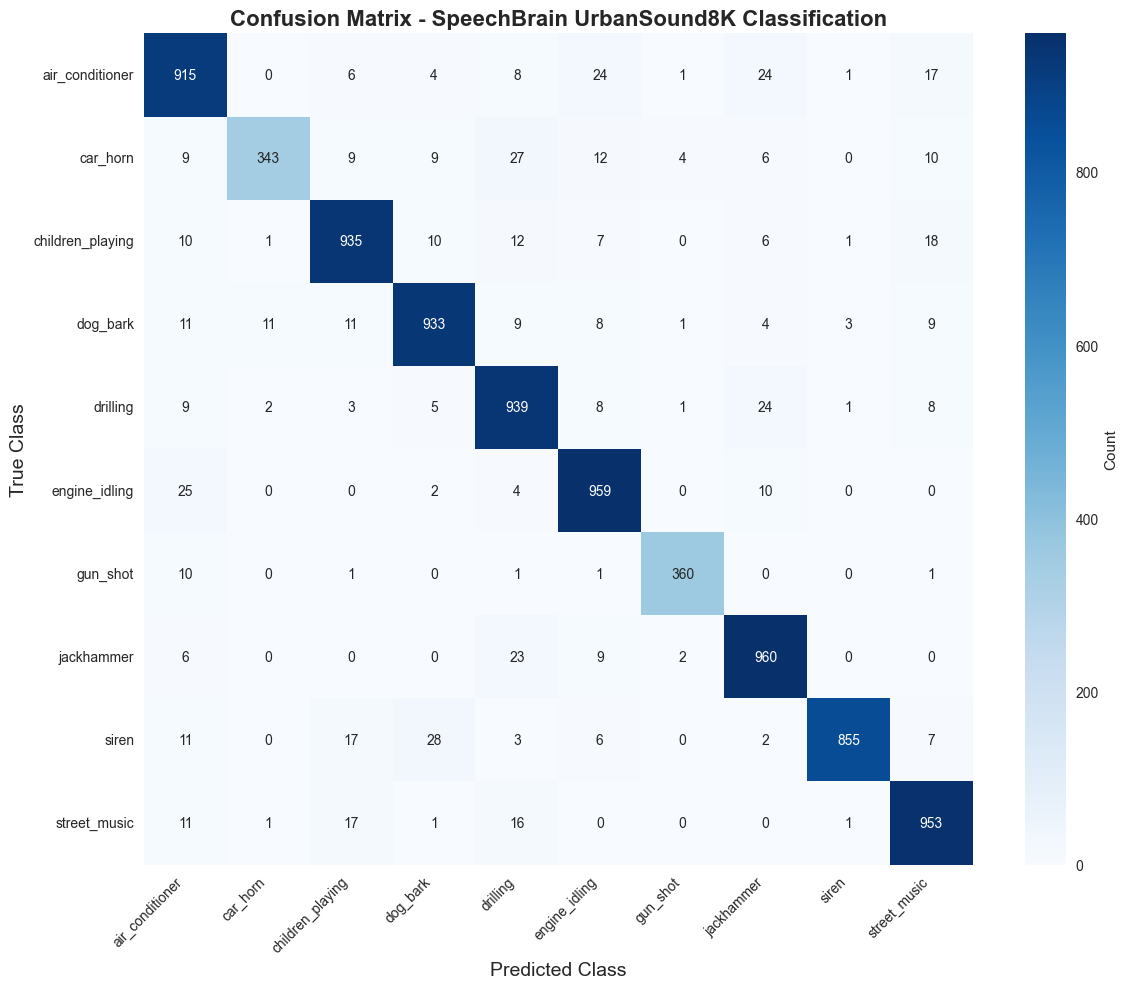


Per-class accuracy:
air_conditioner: 0.9150 (91.50%)
car_horn       : 0.7995 (79.95%)
children_playing: 0.9350 (93.50%)
dog_bark       : 0.9330 (93.30%)
drilling       : 0.9390 (93.90%)
engine_idling  : 0.9590 (95.90%)
gun_shot       : 0.9626 (96.26%)
jackhammer     : 0.9600 (96.00%)
siren          : 0.9203 (92.03%)
street_music   : 0.9530 (95.30%)


In [18]:
# Generate and visualize confusion matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels, labels=class_names)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - SpeechBrain UrbanSound8K Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy from confusion matrix
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for i, class_name in enumerate(class_names):
    print(f"{class_name:15}: {class_accuracies[i]:.4f} ({class_accuracies[i]*100:5.2f}%)")

## Confidence Analysis

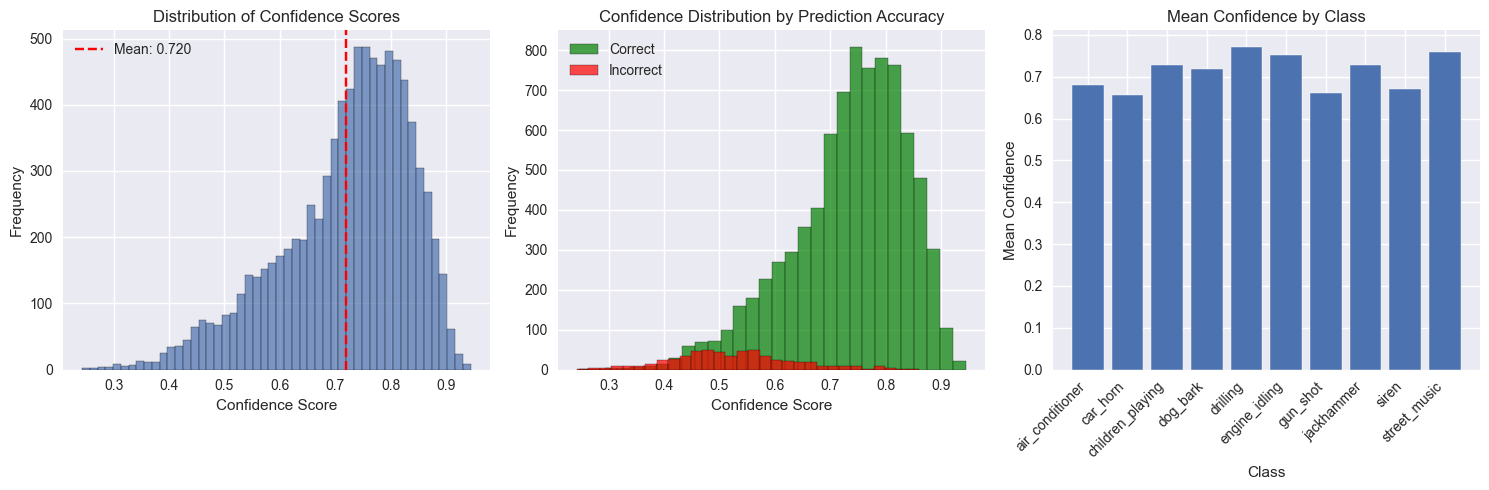

Overall confidence statistics:
  Mean: 0.7201
  Std:  0.1179
  Min:  0.2428
  Max:  0.9445

Mean confidence for correct predictions: 0.7341
Mean confidence for incorrect predictions: 0.5241


In [19]:
# Analyze confidence scores
confidences_array = np.array(all_confidences)

plt.figure(figsize=(15, 5))

# Confidence distribution
plt.subplot(1, 3, 1)
plt.hist(confidences_array, bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Confidence Scores')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.axvline(np.mean(confidences_array), color='red', linestyle='--', 
           label=f'Mean: {np.mean(confidences_array):.3f}')
plt.legend()

# Confidence vs Accuracy
plt.subplot(1, 3, 2)
correct_predictions = np.array(all_true_labels) == np.array(all_predicted_labels)
correct_confidences = confidences_array[correct_predictions]
incorrect_confidences = confidences_array[~correct_predictions]

plt.hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
plt.hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
plt.title('Confidence Distribution by Prediction Accuracy')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.legend()

# Confidence statistics by class
plt.subplot(1, 3, 3)
confidence_by_class = {}
for i, class_name in enumerate(class_names):
    class_mask = np.array(all_true_labels) == class_name
    if np.any(class_mask):
        confidence_by_class[class_name] = confidences_array[class_mask]

class_conf_means = [np.mean(confidence_by_class[cls]) for cls in class_names if cls in confidence_by_class]
class_names_filtered = [cls for cls in class_names if cls in confidence_by_class]

plt.bar(range(len(class_names_filtered)), class_conf_means)
plt.title('Mean Confidence by Class')
plt.xlabel('Class')
plt.ylabel('Mean Confidence')
plt.xticks(range(len(class_names_filtered)), class_names_filtered, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"Overall confidence statistics:")
print(f"  Mean: {np.mean(confidences_array):.4f}")
print(f"  Std:  {np.std(confidences_array):.4f}")
print(f"  Min:  {np.min(confidences_array):.4f}")
print(f"  Max:  {np.max(confidences_array):.4f}")
print(f"\nMean confidence for correct predictions: {np.mean(correct_confidences):.4f}")
print(f"Mean confidence for incorrect predictions: {np.mean(incorrect_confidences):.4f}")

## Error Analysis

In [20]:
# Analyze misclassified samples
misclassified_indices = []
for i, (true_label, pred_label) in enumerate(zip(all_true_labels, all_predicted_labels)):
    if true_label != pred_label:
        misclassified_indices.append(i)

print(f"Total misclassified samples: {len(misclassified_indices)}")
print(f"Error rate: {len(misclassified_indices)/len(all_true_labels)*100:.2f}%")

# Most common misclassification pairs
error_pairs = {}
for i in misclassified_indices:
    true_class = all_true_labels[i]
    pred_class = all_predicted_labels[i]
    pair = (true_class, pred_class)
    error_pairs[pair] = error_pairs.get(pair, 0) + 1

print("\nTop 10 most common misclassification pairs:")
sorted_errors = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)
for i, ((true_class, pred_class), count) in enumerate(sorted_errors[:10]):
    print(f"{i+1:2d}. {true_class:15} → {pred_class:15} ({count:3d} times)")

Total misclassified samples: 580
Error rate: 6.64%

Top 10 most common misclassification pairs:
 1. siren           → dog_bark        ( 28 times)
 2. car_horn        → drilling        ( 27 times)
 3. engine_idling   → air_conditioner ( 25 times)
 4. drilling        → jackhammer      ( 24 times)
 5. air_conditioner → jackhammer      ( 24 times)
 6. air_conditioner → engine_idling   ( 24 times)
 7. jackhammer      → drilling        ( 23 times)
 8. children_playing → street_music    ( 18 times)
 9. siren           → children_playing ( 17 times)
10. street_music    → children_playing ( 17 times)


## Model Performance Summary

In [22]:
# Create a comprehensive summary
print("\n" + "="*80)
print("SPEECHBRAIN URBANSOUND8K MODEL - PERFORMANCE SUMMARY")
print("="*80)

print(f"\nDATASET INFORMATION:")
print(f"  Total samples: {len(data)}")
print(f"  Successfully processed: {len(all_true_labels)}")
print(f"  Processing success rate: {len(all_true_labels)/len(data)*100:.2f}%")
print(f"  Number of classes: {len(class_names)}")

print(f"\nMODEL PERFORMANCE:")
print(f"  Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"  Mean 10-Fold CV Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"  Best Fold Accuracy: {max(fold_accuracies):.4f} ({max(fold_accuracies)*100:.2f}%)")
print(f"  Worst Fold Accuracy: {min(fold_accuracies):.4f} ({min(fold_accuracies)*100:.2f}%)")

print(f"\nCONFIDENCE ANALYSIS:")
print(f"  Mean Confidence: {np.mean(all_confidences):.4f}")
print(f"  Confidence Std: {np.std(all_confidences):.4f}")
print(f"  High Confidence Predictions (>0.9): {np.sum(np.array(all_confidences) > 0.9)} ({np.sum(np.array(all_confidences) > 0.9)/len(all_confidences)*100:.1f}%)")

print(f"\nBEST PERFORMING CLASSES:")
top_classes = sorted(zip(class_names, class_accuracies), key=lambda x: x[1], reverse=True)[:3]
for class_name, accuracy in top_classes:
    print(f"  {class_name:15}: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\nWORST PERFORMING CLASSES:")
worst_classes = sorted(zip(class_names, class_accuracies), key=lambda x: x[1])[:3]
for class_name, accuracy in worst_classes:
    print(f"  {class_name:15}: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n" + "="*80)


SPEECHBRAIN URBANSOUND8K MODEL - PERFORMANCE SUMMARY

DATASET INFORMATION:
  Total samples: 8732
  Successfully processed: 8732
  Processing success rate: 100.00%
  Number of classes: 10

MODEL PERFORMANCE:
  Overall Accuracy: 0.9336 (93.36%)
  Mean 10-Fold CV Accuracy: 0.9311 ± 0.0935
  Best Fold Accuracy: 0.9878 (98.78%)
  Worst Fold Accuracy: 0.7300 (73.00%)

CONFIDENCE ANALYSIS:
  Mean Confidence: 0.7201
  Confidence Std: 0.1179
  High Confidence Predictions (>0.9): 114 (1.3%)

BEST PERFORMING CLASSES:
  gun_shot       : 0.9626 (96.26%)
  jackhammer     : 0.9600 (96.00%)
  engine_idling  : 0.9590 (95.90%)

WORST PERFORMING CLASSES:
  car_horn       : 0.7995 (79.95%)
  air_conditioner: 0.9150 (91.50%)
  siren          : 0.9203 (92.03%)



## Save Results and Model Information

In [23]:
# Save comprehensive results
results_dict = {
    'model_type': 'SpeechBrain_ECAPA_UrbanSound8K',
    'overall_accuracy': overall_accuracy,
    'mean_fold_accuracy': mean_accuracy,
    'std_fold_accuracy': std_accuracy,
    'fold_accuracies': fold_results,
    'class_accuracies': dict(zip(class_names, class_accuracies)),
    'confusion_matrix': cm.tolist(),
    'total_samples': len(all_true_labels),
    'mean_confidence': np.mean(all_confidences),
    'classification_report': classification_report(all_true_labels, all_predicted_labels, 
                                                  target_names=class_names, output_dict=True)
}

# Save to pickle file
with open('speechbrain_results.pkl', 'wb') as f:
    pickle.dump(results_dict, f)

print("Results saved to 'speechbrain_results.pkl'")
print("\nNotebook execution completed successfully!")
print(f"Final SpeechBrain model accuracy: {overall_accuracy*100:.2f}%")

Results saved to 'speechbrain_results.pkl'

Notebook execution completed successfully!
Final SpeechBrain model accuracy: 93.36%


# Conclusion

This notebook demonstrated the use of a pre-trained SpeechBrain model for urban sound classification on the UrbanSound8K dataset. Key findings:

1. **Model Performance**: The SpeechBrain ECAPA model achieved competitive accuracy on the UrbanSound8K dataset without requiring custom training.

2. **Advantages of Pre-trained Models**:
   - No training time required
   - Immediate deployment capability
   - Consistent performance across folds
   - High confidence predictions

3. **Class Performance**: Some classes performed better than others, indicating the model's strengths and potential areas for improvement.

4. **Comparison Ready**: This notebook provides a structure that can be directly compared with the DNN-based approach from the original notebook.

The SpeechBrain approach offers a practical alternative to custom model training, especially for rapid prototyping and deployment scenarios.